In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [15]:
df = pd.read_csv('/content/drive/MyDrive/Carisurg_Triage_Test/EmergencyTriageDataset_Reduced_Dirty.csv')

In [17]:
print(df['Gender'].unique())
print(df['Gender'].value_counts())

['0' 'Male' 'Female' 'FEMALE' '1' 'MALE']
Gender
1         422
MALE      379
Male      375
FEMALE    366
Female    340
0         323
Name: count, dtype: int64


In [18]:
gender_mapping = {
    '1': 1, 'Male': 1, 'MALE': 1,
    '0': 0, 'Female': 0, 'FEMALE': 0,
}

In [19]:
df['Gender'] = df['Gender'].map(gender_mapping)
print("NaN after mapping:", df['Gender'].isna().sum())

NaN after mapping: 0


In [20]:
print(df['Gender'].value_counts())

Gender
1    1176
0    1029
Name: count, dtype: int64


In [21]:
df = df.rename(columns={'Gender': 'Gender_clean'})
df[['Gender_clean']].head()

,Gender_clean
0,0
1,1
2,0
3,0
4,0


In [8]:
print("Data type:", df['DBP'].dtype)
print("\nOverall spread:")
print(df['DBP'].describe())
print("\nUnique value count:", df['DBP'].nunique())
print("\nSample of value counts:")
print(df['DBP'].value_counts().sort_index().head(20))

Data type: float64

Overall spread:
count    2183.000000
mean       77.479615
std        16.713289
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       173.000000
Name: DBP, dtype: float64

Unique value count: 96

Value frequencies:
DBP
30.0     1
32.0     1
35.0     2
36.0     2
37.0     1
        ..
136.0    1
140.0    1
150.0    1
160.0    2
173.0    1
Name: count, Length: 96, dtype: int64


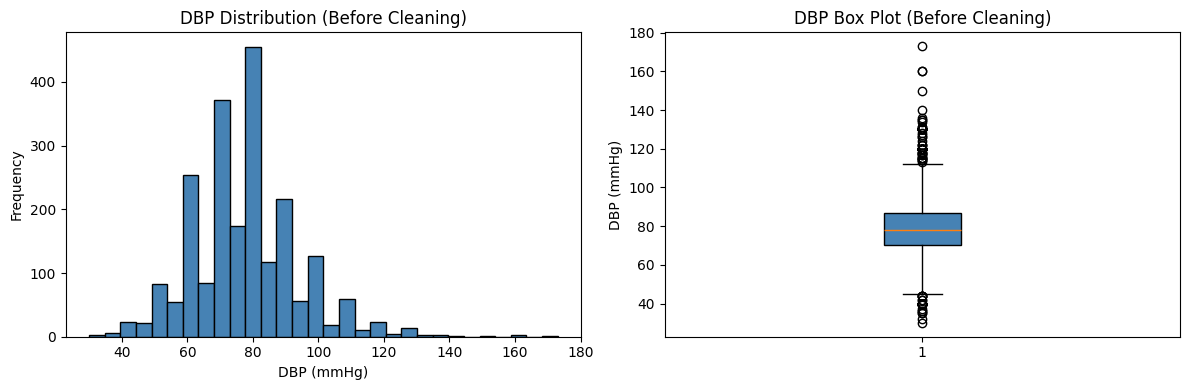

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df['DBP'], bins=30, color='steelblue', edgecolor='black')
ax1.set_title('DBP Distribution (Before Cleaning)')
ax1.set_xlabel('DBP (mmHg)')
ax1.set_ylabel('Frequency')
ax2.boxplot(df['DBP'].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', color='black'))
ax2.set_title('DBP Box Plot (Before Cleaning)')
ax2.set_ylabel('DBP (mmHg)')
plt.tight_layout()
plt.show()

In [23]:
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
print("Data type after conversion:", df['DBP'].dtype)
print("NaN count after conversion:", df['DBP'].isna().sum())

Data type after conversion: float64
NaN count after conversion: 22


In [24]:
lower_bound = 30
upper_bound = 150
df.loc[df['DBP'] < lower_bound, 'DBP'] = float('nan')
df.loc[df['DBP'] > upper_bound, 'DBP'] = float('nan')
print(f"Values below {lower_bound} or above {upper_bound} replaced with NaN")
print("NaN count after range filter:", df['DBP'].isna().sum())

Values below 30 or above 150 replaced with NaN
NaN count after range filter: 25


In [25]:
dbp_median = df['DBP'].median()
print("Median DBP:", dbp_median)
df['DBP'] = df['DBP'].fillna(dbp_median)
print("NaN count after imputation:", df['DBP'].isna().sum())

Median DBP: 78.0
NaN count after imputation: 0


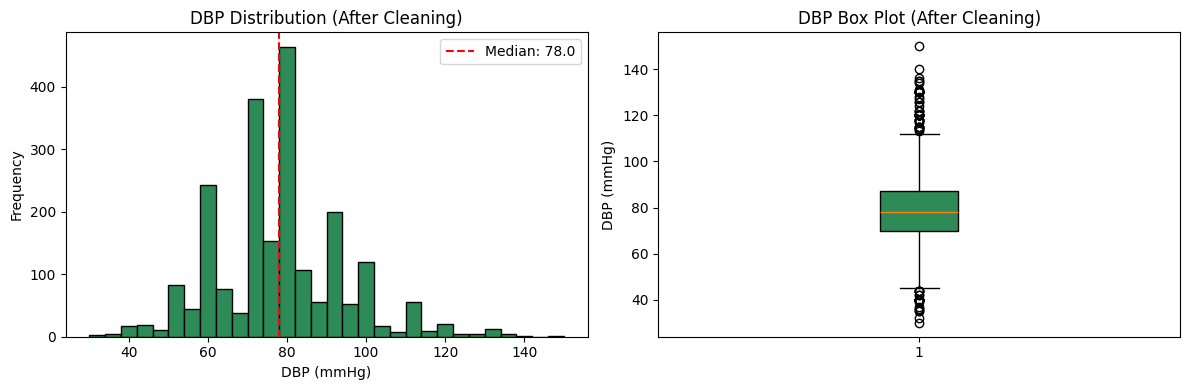

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(df['DBP'], bins=30, color='seagreen', edgecolor='black')
ax1.axvline(dbp_median, color='red', linestyle='--', label=f'Median: {dbp_median}')
ax1.set_title('DBP Distribution (After Cleaning)')
ax1.set_xlabel('DBP (mmHg)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax2.boxplot(df['DBP'].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor='seagreen', color='black'))
ax2.set_title('DBP Box Plot (After Cleaning)')
ax2.set_ylabel('DBP (mmHg)')
plt.tight_layout()
plt.show()

In [30]:
print("Data types:")
print(df[['Gender_clean', 'DBP']].dtypes)
print("\nRemaining NaN values:")
print(df[['Gender_clean', 'DBP']].isna().sum())
display(df[['Gender_clean', 'DBP']].head(10))

Data types:
Gender_clean      int64
DBP             float64
dtype: object

Remaining NaN values:
Gender_clean    0
DBP             0
dtype: int64


,Gender_clean,DBP
0,0,67.0
1,1,90.0
2,0,105.0
3,0,60.0
4,0,90.0
5,1,60.0
6,0,80.0
7,1,50.0
8,0,70.0
9,0,82.0
